# 04 — VF Preprocessing (Real UWHVF Data)

Build the model-ready dataset directly from the real UWHVF `alldata.json`.

**Filters**
- ≥ 3 visits per patient-eye, ≥ 1.0 yr follow-up, MD rate ∈ [–10, 5] dB/yr

**Outputs**
- `data/processed/patients.parquet` — 4,276 patient-eye records
- `data/processed/vf_{id}.npy` — (T×54) normalised TD arrays
- `data/splits/{train,val,test}_ids.txt` — stratified 70/15/15

In [5]:
import sys, subprocess
sys.path.insert(0, "..")
from pathlib import Path
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

PROC_DIR   = Path('../data/processed')
SPLITS_DIR = Path('../data/splits')
print('Processed dir exists:', PROC_DIR.exists())

Processed dir exists: True


## 1. Run Preprocessing Script (if needed)

In [6]:
if not (PROC_DIR / 'patients.parquet').exists():
    r = subprocess.run(['uv','run','python','scripts/preprocess_uwhvf.py'],
                       capture_output=True, text=True, cwd='..')
    print(r.stdout)
    if r.returncode != 0: print('STDERR:', r.stderr)
else:
    print('Data already processed.')

Data already processed.


## 2. Load & Summarise

In [7]:
patients  = pl.read_parquet(PROC_DIR / 'patients.parquet')
md_rates  = patients['md_rate_db_year'].to_numpy()
n_visits  = patients['n_visits'].to_numpy()
follow_up = patients['follow_up_years'].to_numpy()

print(f'Patient-eyes:              {len(patients):,}')
print(f'Fast progressors (< -1):   {(md_rates < -1).sum():,}  ({(md_rates < -1).mean()*100:.1f}%)')
print(f'MD rate mean ± std:         {md_rates.mean():.3f} ± {md_rates.std():.3f} dB/yr')
print(f'Visits/eye (mean, median):  {n_visits.mean():.1f}, {int(np.median(n_visits))}')
print(f'Follow-up (mean, median):   {follow_up.mean():.1f} yr, {np.median(follow_up):.1f} yr')

Patient-eyes:              4,276
Fast progressors (< -1):   394  (9.2%)
MD rate mean ± std:         -0.126 ± 0.956 dB/yr
Visits/eye (mean, median):  5.2, 4
Follow-up (mean, median):   5.8 yr, 4.3 yr


## 3. Progression Rate Distributions

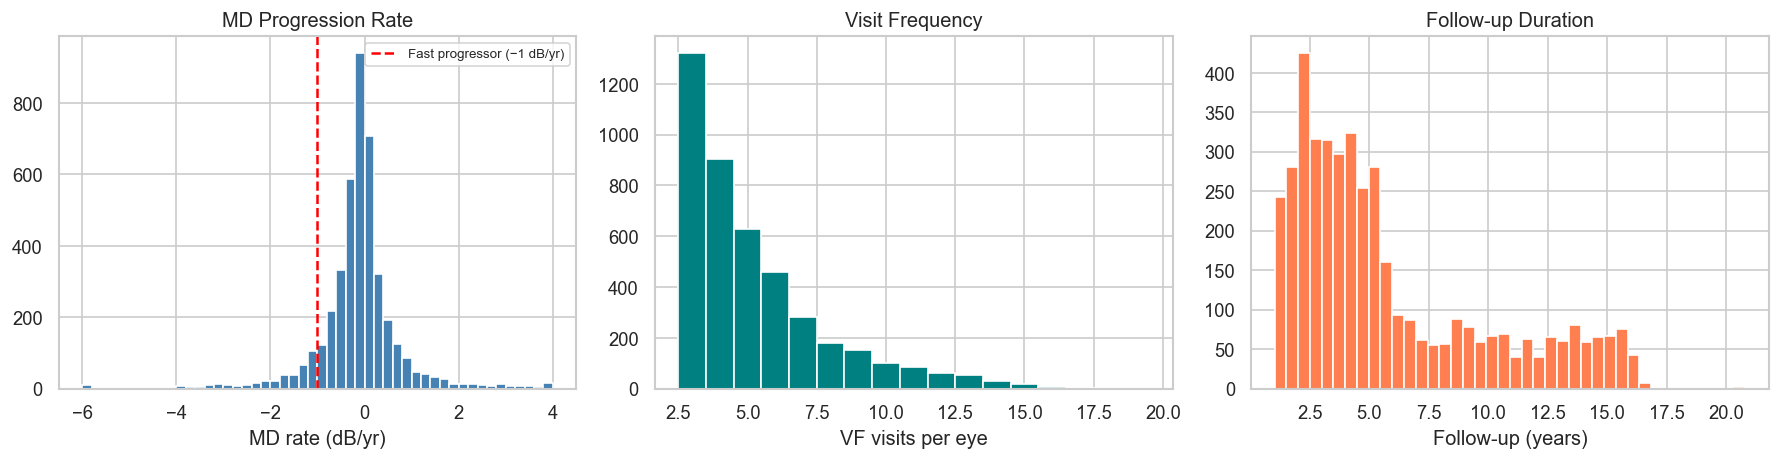

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(np.clip(md_rates, -6, 4), bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(-1.0, color='red', ls='--', lw=1.5, label='Fast progressor (−1 dB/yr)')
axes[0].set_xlabel('MD rate (dB/yr)'); axes[0].set_title('MD Progression Rate')
axes[0].legend(fontsize=8)

axes[1].hist(n_visits, bins=np.arange(3, min(n_visits.max(), 20)+2)-0.5, color='teal', edgecolor='white')
axes[1].set_xlabel('VF visits per eye'); axes[1].set_title('Visit Frequency')

axes[2].hist(follow_up, bins=40, color='coral', edgecolor='white')
axes[2].set_xlabel('Follow-up (years)'); axes[2].set_title('Follow-up Duration')

plt.tight_layout()
plt.savefig('../reports/04_preprocessing_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Verify VF Series & Confirm Splits

In [9]:
for pid in patients['patient_id'].head(3).to_list():
    arr = np.load(PROC_DIR / f'vf_{pid}.npy')
    print(f'{pid}: shape={arr.shape}, range=[{arr.min():.3f}, {arr.max():.3f}]')

print()
for split in ['train', 'val', 'test']:
    ids = (SPLITS_DIR / f'{split}_ids.txt').read_text().strip().splitlines()
    sub = patients.filter(pl.col('patient_id').is_in(ids))
    fp_pct = (sub['md_rate_db_year'].to_numpy() < -1).mean() * 100
    print(f'{split:5s}: {len(ids):,} eyes | fast progressors: {fp_pct:.1f}%')

647_L: shape=(11, 54), range=[0.036, 1.000]
647_R: shape=(11, 54), range=[0.629, 1.000]
2975_L: shape=(6, 54), range=[0.426, 1.000]

train: 2,992 eyes | fast progressors: 8.8%
val  : 640 eyes | fast progressors: 9.2%
test : 644 eyes | fast progressors: 11.0%
